# **Neuroengineering project - Neural decoding**

**Tutor**: Lorenzo Veronese, lorenzo.veronese@polimi.it

**Sub-projects**:
1. *ROI-based neural decoding*. Explore different variations of ROIs. How does model performance change according to the ROI? Does certain ROIs better predict certain superclasses?
2. *Architecture search*. Look for the best architecture to perform the task (using fully connected layers, CNN, RNN...) and maximize the prediction performance.
3. *Class vs. superclass*. Predict the classes instead of the superclasses. How does the neural decoding performance change?
4. *Explainability*. Explore explainability techniques to backtrack the constribution of different voxels in the reconstruction. Which voxels contributed the most to the predictions?
5. *Dimensionality reduction*. Reduce the dimensionality of the activation maps by encoding them into a smaller space (PCA, tSNE...).



## Setup

In [23]:
from pathlib import Path

# Portable paths: run Jupyter from the repository root.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "supporting":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", PROJECT_ROOT / "data")
print("Output directory:", OUTPUT_DIR)


Mounted at /content/drive


In [24]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models

%matplotlib inline

Change the following path according to your environment

In [25]:
# The portable setup cell selects the repository root.
os.chdir(PROJECT_ROOT)


## Data loading and inspection

Data comes from the Generic Object Decoding (GOD, fMRI on ImageNet) dataset, with some adaptations: https://github.com/KamitaniLab/GenericObjectDecoding/tree/master

#### Main data

In [26]:
dataset = pd.read_pickle("data/god_with_superclass.pkl")

In [27]:
print(dataset.head())

   activation_map_id                                     activation_map  \
0                  1  [1.766656627524694, -0.2588433067069715, -1.94...   
1                  2  [1.1331745001682942, 0.3439989708662981, -1.52...   
2                  3  [1.7567031594701399, 0.9317526350205484, -0.59...   
3                  4  [1.6469755265546766, 0.5387464269385586, -1.54...   
4                  5  [1.5110601689171665, -0.2767409568759731, -1.3...   

                                            stimulus imagenet_class_wnid  \
0  [[[0.3333333333333333, 0.4549019607843137, 0.5...     n01518878_10042   
1  [[[0.11372549019607843, 0.13725490196078433, 0...     n01518878_12028   
2  [[[0.8901960784313725, 0.796078431372549, 0.64...     n01518878_14075   
3  [[[0.5882352941176471, 0.5450980392156862, 0.4...     n01518878_14910   
4  [[[0.48627450980392156, 0.5803921568627451, 0....      n01518878_5958   

  imagenet_class_name superclass  
0             ostrich       Bird  
1             ostrich 

In [28]:
print(dataset.dtypes)
print("\nObject? Not as detailed as we want. Let's try another thing:")
for col in dataset.columns:
    unique_types = dataset[col].map(type).unique()
    print(f"{col}: {unique_types}")

activation_map_id       int64
activation_map         object
stimulus               object
imagenet_class_wnid    object
imagenet_class_name    object
superclass             object
dtype: object

Object? Not as detailed as we want. Let's try another thing:
activation_map_id: [<class 'int'>]
activation_map: [<class 'numpy.ndarray'>]
stimulus: [<class 'numpy.ndarray'>]
imagenet_class_wnid: [<class 'str'>]
imagenet_class_name: [<class 'str'>]
superclass: [<class 'str'>]


Sample index: 622
activation_map_id: 623


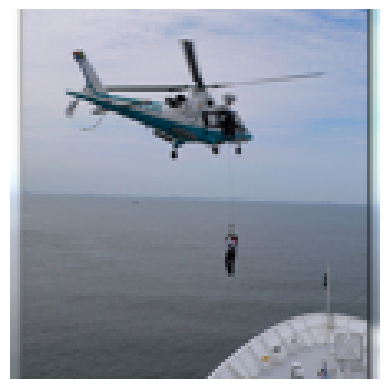

imagenet_class_wnid: n03512147_5054
imagenet_class_name: helicopter
superclass: Vehicles
Sample index: 130
activation_map_id: 131


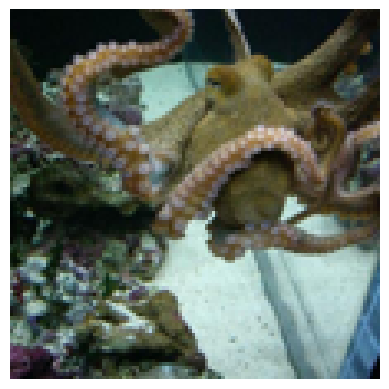

imagenet_class_wnid: n01970164_19716
imagenet_class_name: octopus
superclass: Invertebrates
Sample index: 195
activation_map_id: 196


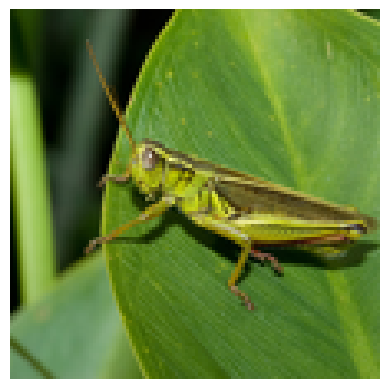

imagenet_class_wnid: n02226429_14311
imagenet_class_name: grasshopper
superclass: Invertebrates
Sample index: 253
activation_map_id: 254


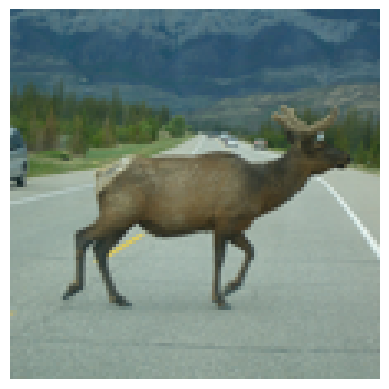

imagenet_class_wnid: n02432983_24646
imagenet_class_name: elk
superclass: Other mammals
Sample index: 450
activation_map_id: 451


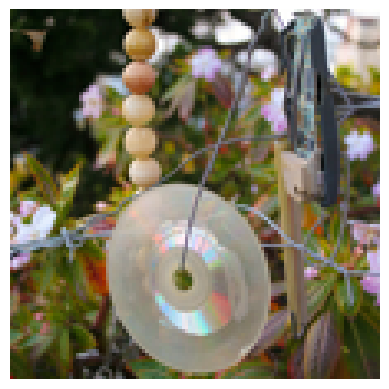

imagenet_class_wnid: n03079230_20064
imagenet_class_name: compact_disk
superclass: Electronics, Computing
Sample index: 217
activation_map_id: 218


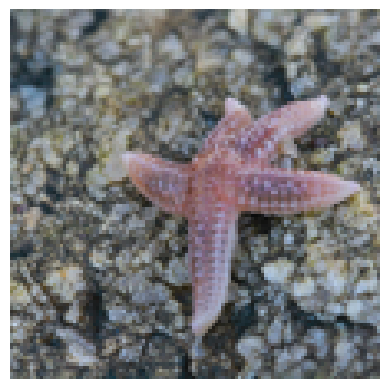

imagenet_class_wnid: n02317335_14310
imagenet_class_name: starfish
superclass: Invertebrates
Sample index: 775
activation_map_id: 776


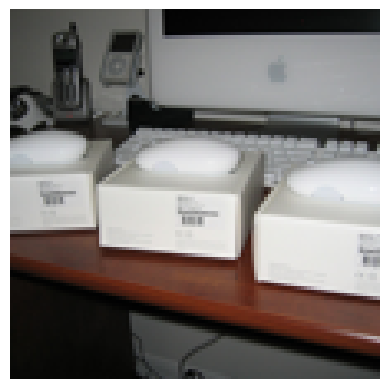

imagenet_class_wnid: n03793489_8932
imagenet_class_name: mouse
superclass: Electronics, Computing
Sample index: 653
activation_map_id: 654


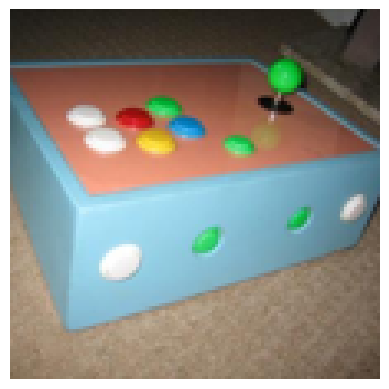

imagenet_class_wnid: n03602883_16220
imagenet_class_name: joystick
superclass: Tools, Mechanical
Sample index: 143
activation_map_id: 144


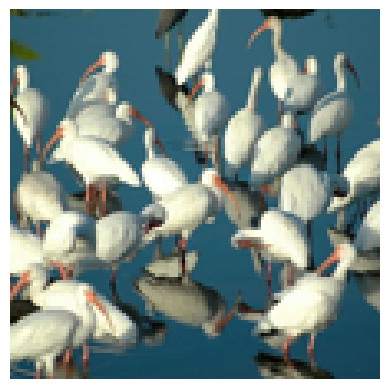

imagenet_class_wnid: n02005790_9371
imagenet_class_name: ibis
superclass: Bird
Sample index: 1188
activation_map_id: 1189


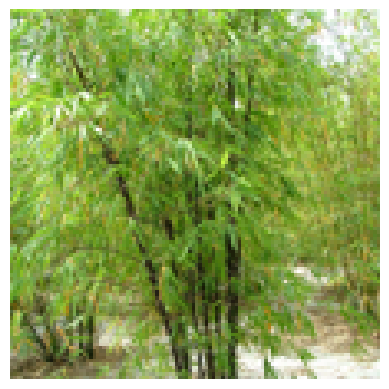

imagenet_class_wnid: n12596148_6386
imagenet_class_name: miniature_fan_palm
superclass: Food, plants, fungi


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import random

# Number of samples to display
n_samples = 10

# Pick random indices
random_indices = random.sample(range(len(dataset)), n_samples)

for idx in random_indices:
    row = dataset.iloc[idx]
    print(f"Sample index: {idx}")

    # Print all columns except 'activation_map'
    for col in dataset.columns:
        if col != 'activation_map':
            if col == 'stimulus':  # If it's an image, show it
                plt.imshow(row[col])
                plt.axis('off')
                plt.show()
            else:
                print(f"{col}: {row[col]}")
    print("="*50)


#### ROIs

In [30]:
rois = dict(np.load("data/roi_masks.npz", allow_pickle=True))

In [31]:
possible_rois = rois.keys()
print(possible_rois)

dict_keys(['V1', 'V2', 'V3', 'V4', 'FFA', 'PPA', 'LOC', 'LVC', 'HVC', 'VC'])


In [32]:
for roi, mask in rois.items():
    n_voxels = mask.sum()   # counts True values
    print(f"{roi}: {n_voxels} voxels")

V1: 1004 voxels
V2: 1018 voxels
V3: 759 voxels
V4: 740 voxels
FFA: 568 voxels
PPA: 356 voxels
LOC: 540 voxels
LVC: 2281 voxels
HVC: 2049 voxels
VC: 4466 voxels


In [33]:
import numpy as np

chosen_roi = "VC"

# Apply ROI mask to each row
dataset[f"activation_map_{chosen_roi}"] = dataset["activation_map"].apply(
    lambda x: x[rois[chosen_roi]]
) #when using VC, this new column will be a replica of activation_map

In [34]:
print("Number of voxels after masking for this ROI: ", len(dataset[f"activation_map_{chosen_roi}"][0]))

Number of voxels after masking for this ROI:  4466


#### 3D visualization of the activation map

In [35]:
import numpy as np
import plotly.graph_objects as go
from skimage import measure
import nibabel as nib
## Choose volume to visualize (e.g. the first one)
activation_map_to_show = dataset[f'activation_map_{chosen_roi}'][0]

## Load subject T1-weighted anatomical scan (it will be the background for our visualization)
t1_img = nib.load("data/Subject1_T1wAligned.nii")
t1_data = t1_img.get_fdata()
template_shape = t1_data.shape

## Load voxel 3D coordinates (mapping from 1D flattened activation map to 3D)
voxel_coords = np.load('data/voxel_coords.npz')

x = voxel_coords['x']
y = voxel_coords['y']
z = voxel_coords['z']

## Normalize ROI coordinates to start at 0
x = x - x.min()
y = y - y.min()
z = z - z.min()

## Scale ROI to fit in template (occipital lobe region)
roi_size = np.array([x.max(), y.max(), z.max()])
roi_center = roi_size / 2
template_center = np.array(template_shape) / 2  # center of T1
offset = template_center - roi_center
x_t = np.clip((x + offset[0]).astype(int), 0, template_shape[0]-1)
y_t = np.clip((y + offset[1]).astype(int), 0, template_shape[1]-1)
z_t = np.clip((z + offset[2]).astype(int), 0, template_shape[2]-1)

## Various tweaks to put the 3D activation map in the right position
# Adjust ROI coordinates for translation ---
x_offset_move = -5   # move forward along x-axis
y_offset_move = -45  # move back along y-axis
z_offset_move = 0    # no change along z-axis
x_t_moved = np.clip(x_t + x_offset_move, 0, template_shape[0]-1)
y_t_moved = np.clip(y_t + y_offset_move, 0, template_shape[1]-1)
z_t_moved = z_t + z_offset_move

# Mirror blob along x-axis
x_t_flipped = template_shape[0] - 1 - x_t_moved

## Ensure lengths match ROI voxel values ---
num_voxels = activation_map_to_show.shape[0]
x_t_flipped = x_t_flipped[:num_voxels]
y_t_moved = y_t_moved[:num_voxels]
z_t_moved = z_t_moved[:num_voxels]

## Create activation volume safely ---
volume = np.zeros(template_shape)
for i in range(num_voxels):
    xi = int(x_t_flipped[i])
    yi = int(y_t_moved[i])
    zi = int(z_t_moved[i])
    volume[xi, yi, zi] = activation_map_to_show[i]

## Optional rotation if needed ---
# volume = np.rot90(volume, k=1, axes=(1, 2))  # rotate top
# volume = np.rot90(volume, k=1, axes=(0, 2))  # rotate right

## T1 surface
t1_threshold = np.percentile(t1_data, 70)
verts, faces, _, _ = measure.marching_cubes(t1_data, level=t1_threshold)
t1_mesh = go.Mesh3d(
    x=verts[:,0], y=verts[:,1], z=verts[:,2],
    i=faces[:,0], j=faces[:,1], k=faces[:,2],
    color='lightgray', opacity=0.3, name='Subject T1'
)

##Activation surface
threshold = np.percentile(volume[volume>0], 10)
verts_act, faces_act, _, _ = measure.marching_cubes(volume, level=threshold)

## Map vertex intensities from the volume
# nearest neighbor interpolation from voxel values to vertices
xv = np.clip(verts_act[:,0].astype(int), 0, template_shape[0]-1)
yv = np.clip(verts_act[:,1].astype(int), 0, template_shape[1]-1)
zv = np.clip(verts_act[:,2].astype(int), 0, template_shape[2]-1)
intensity = volume[xv, yv, zv]

act_mesh = go.Mesh3d(
    x=verts_act[:,0], y=verts_act[:,1], z=verts_act[:,2],
    i=faces_act[:,0], j=faces_act[:,1], k=faces_act[:,2],
    intensity=intensity,  # this makes color reflect values
    colorscale='Reds',
    opacity=0.6,
    name='Activation'
)

## Plot
fig = go.Figure(data=[t1_mesh, act_mesh])
fig.update_layout(
    scene=dict(
        xaxis_title='X (mm)', yaxis_title='Y (mm)', zaxis_title='Z (mm)',
        aspectmode='data'
    ),
    title="fMRI Activations over Subject T1"
)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

## Preprocessing

Labelling for multi-class classification

In [36]:
# Input preparation
X = np.stack(dataset['activation_map'].values)

# Encode superclass labels
le = LabelEncoder()
y = le.fit_transform(dataset['superclass'].values)

# Number of classes
num_classes = len(le.classes_)

# One-hot encode labels
y = tf.keras.utils.to_categorical(y, num_classes=num_classes)

In [37]:
print("Number of classes:", len(y[0]))
# Mapping: one-hot vector -> class name
print("One-hot vector -> Class name mapping:")
for idx, cls in enumerate(le.classes_):
    one_hot = np.zeros(num_classes, dtype=int)
    one_hot[idx] = 1
    print(f"{one_hot.tolist()} -> {cls}")

Number of classes: 14
One-hot vector -> Class name mapping:
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] -> Bird
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] -> Clothes, covering
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] -> Dogs
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] -> Electronics, Computing
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0] -> Food, plants, fungi
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0] -> Implements, containers, misc. objects
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0] -> Invertebrates
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0] -> Medical, Health
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0] -> Other mammals
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] -> Recreational, Musical
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0] -> Reptiles, fish, amphibians
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0] -> Structures, furnishing
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0] -> Tools, Mechanical
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1] -> Vehicles


Train-test-validation split

In [38]:
'''
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
'''

'\nX_temp, X_test, y_temp, y_test = train_test_split(\n    X, y, test_size=0.15, random_state=42, stratify=y\n)\n'

In [39]:
'''
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 ≈ 0.15/(1-0.15) to get 15% of total
)
'''

'\nX_train, X_val, y_train, y_val = train_test_split(\n    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 ≈ 0.15/(1-0.15) to get 15% of total\n)\n'

Data normalization

In [40]:
'''
# Z-score normalization (fit on training data only)
train_means = np.array([sample.mean() for sample in X_train])
train_stds = np.array([sample.std() + 1e-8 for sample in X_train])

# Apply normalization to all splits
X_train_normalized = np.array([
    (X_train[i] - train_means[i]) / train_stds[i]
    for i in range(len(X_train))
])

X_val_normalized = np.array([
    (X_val[i] - train_means[i % len(train_means)]) / train_stds[i % len(train_stds)]
    for i in range(len(X_val))
])

X_test_normalized = np.array([
    (X_test[i] - train_means[i % len(train_means)]) / train_stds[i % len(train_stds)]
    for i in range(len(X_test))
])

# Use normalized data
X_train, X_val, X_test = X_train_normalized, X_val_normalized, X_test_normalized
'''

'\n# Z-score normalization (fit on training data only)\ntrain_means = np.array([sample.mean() for sample in X_train])\ntrain_stds = np.array([sample.std() + 1e-8 for sample in X_train])\n\n# Apply normalization to all splits\nX_train_normalized = np.array([\n    (X_train[i] - train_means[i]) / train_stds[i]\n    for i in range(len(X_train))\n])\n\nX_val_normalized = np.array([\n    (X_val[i] - train_means[i % len(train_means)]) / train_stds[i % len(train_stds)]\n    for i in range(len(X_val))\n])\n\nX_test_normalized = np.array([\n    (X_test[i] - train_means[i % len(train_means)]) / train_stds[i % len(train_stds)]\n    for i in range(len(X_test))\n])\n\n# Use normalized data\nX_train, X_val, X_test = X_train_normalized, X_val_normalized, X_test_normalized\n'

In [42]:
# --- BLOCCO 1 AGGIORNATO: Preparazione Dati Dual-Task ---
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# 1. Encode Superclasses (come prima)
le_super = LabelEncoder()
y_super_indices = le_super.fit_transform(dataset['superclass'].values)
y_super = to_categorical(y_super_indices)

# 2. Encode Classes (NUOVO: predire l'oggetto specifico)
# ATTENZIONE: Verifica che la colonna si chiami 'target', 'class', o 'label' nel tuo dataframe!
# Qui assumo si chiami 'target'. Se ti dà errore, stampa dataset.columns per controllare.
colonna_classe = 'imagenet_class_name' # Correzione: usa il nome della colonna corretta
le_class = LabelEncoder()
y_class_indices = le_class.fit_transform(dataset[colonna_classe].values)
y_class = to_categorical(y_class_indices)

print(f"Superclassi: {len(le_super.classes_)}, Classi: {len(le_class.classes_)}")

# 3. Split Unico (Così X, y_super e y_class sono perfettamente allineati)
# Nota: Dividiamo X (raw), y_super e y_class insieme
X_temp, X_test, y_sup_temp, y_sup_test, y_cls_temp, y_cls_test = train_test_split(
    X, y_super, y_class, test_size=0.15, random_state=42, stratify=y_super
)

X_train, X_val, y_sup_train, y_sup_val, y_cls_train, y_cls_val = train_test_split(
    X_temp, y_sup_temp, y_cls_temp, test_size=0.176, random_state=42, stratify=y_sup_temp
)

# 4. Normalizzazione (Z-score per sample, come nel tuo codice originale)
# La ri-applichiamo qui perché abbiamo ricreato X_train/val/test da zero
train_means = np.array([sample.mean() for sample in X_train])
train_stds = np.array([sample.std() + 1e-8 for sample in X_train])

X_train = np.array([(X_train[i] - train_means[i]) / train_stds[i] for i in range(len(X_train))])
# Per val e test usiamo mean/std calcolate su se stessi (sample-wise normalization) o quelle del train?
# Nel tuo codice originale usavi indici modulo (un po' rischioso), qui faccio la sample-wise standard:
X_val = np.array([(X_val[i] - X_val[i].mean()) / (X_val[i].std() + 1e-8) for i in range(len(X_val))])
X_test = np.array([(X_test[i] - X_test[i].mean()) / (X_test[i].std() + 1e-8) for i in range(len(X_test))])

print("Dati pronti. Shape X_train:", X_train.shape)


Superclassi: 14, Classi: 150
Dati pronti. Shape X_train: (840, 4466)


In [44]:
import numpy as np

def compute_roi_weights(dataset, roi_path='roi_masks.npz'):
    # Carica le maschere ROI
    masks = np.load(roi_path)
    roi_names = masks.files # Elenco delle ROI (V1, V2, PPA, ecc)

    # Recupera tutte le voxel mask e crea una mappa unica (voxel_index -> roi_index)
    # Per semplicità, qui calcoliamo la media di attivazione per ROI

    # Ottieni le superclassi uniche
    unique_supers = np.unique(dataset['superclass'].values)
    n_supers = len(unique_supers)
    n_voxels = len(dataset['activation_map'].iloc[0])

    # Matrice dei Pesi: [N_Superclassi x N_Voxels]
    # Inizializziamo tutto a 1.0 (neutro)
    attention_matrix = np.ones((n_supers, n_voxels), dtype=np.float32)

    print("Calcolo attivazione media per ROI...")

    for i, super_cls in enumerate(unique_supers):
        # 1. Prendi tutte le mappe di questa superclasse
        subset = dataset[dataset['superclass'] == super_cls]['activation_map'].values
        subset_matrix = np.stack(subset)

        # Media di attivazione globale per questa superclasse (per ogni voxel)
        mean_activity = np.mean(subset_matrix, axis=0)
        # Normalizziamo tra 0 e 1 per usarlo come "peso"
        # (Opzionale: puoi usare Softmax o MinMax scaling)
        mean_activity = (mean_activity - mean_activity.min()) / (mean_activity.max() - mean_activity.min() + 1e-8)

        # Amplifichiamo il segnale:
        # I voxel molto attivi valgono 1.5x, quelli poco attivi 0.5x
        weight_vector = 0.5 + mean_activity

        # Assegna alla matrice.
        # NB: Assicurati che l'ordine delle superclassi sia lo stesso del LabelEncoder!
        idx_in_encoder = le_super.transform([super_cls])[0]
        attention_matrix[idx_in_encoder, :] = weight_vector

    return attention_matrix

# Esegui l'analisi
ROI_WEIGHTS = compute_roi_weights(dataset, roi_path="data/roi_masks.npz") # FIX: Updated roi_path
print("Shape Matrice Pesi:", ROI_WEIGHTS.shape) # Dovrebbe essere (5, num_voxels)


Calcolo attivazione media per ROI...
Shape Matrice Pesi: (14, 4466)


In [49]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# Parametri
input_dim = X_train.shape[1]
num_superclasses = y_sup_train.shape[1]
num_classes = y_cls_train.shape[1]

# --- 1. Input ---
inputs = Input(shape=(input_dim,), name='brain_input')

# --- 2. Ramo Superclasse (Baseline) ---
x1 = layers.Dense(256, activation='relu')(inputs)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Dropout(0.4)(x1)
x1 = layers.Dense(128, activation='relu')(x1)

# Output Superclasse (usato sia come output che come gate)
out_superclass = layers.Dense(num_superclasses, activation='softmax', name='superclass_output')(x1)

# --- 3. Attention Gating Mechanism (La tua idea!) ---
# Trucco Keras: Usiamo un layer Dense con pesi FISSATI (non trainabili)
# Questo layer fa il prodotto scalare tra la probabilità della superclasse e la tua matrice ROI
# Input: (Batch, 5) dot (5, Voxel) -> Output: (Batch, Voxel) = Maschera di Attenzione

# Explicitly convert ROI_WEIGHTS to a TensorFlow constant
ROI_WEIGHTS_TF = tf.constant(ROI_WEIGHTS, dtype=tf.float32)

# Create a constant initializer for the kernel weights
kernel_initializer_constant = tf.keras.initializers.Constant(ROI_WEIGHTS_TF)

attention_mask = layers.Dense(
    input_dim,
    use_bias=False,
    activation='linear',
    trainable=False, # IMPORTANTE: Non modifichiamo la tua analisi durante il training!
    kernel_initializer=kernel_initializer_constant, # Use kernel_initializer instead of 'weights'
    name='attention_generation'
)(out_superclass)

# Applica la maschera all'input originale (Soft Masking)
gated_input = layers.Multiply(name='gating')([inputs, attention_mask])

# --- 4. Ramo Classi (Condizionato) ---
# Ora usiamo l'input "pulito" dall'attenzione
x2 = layers.Dense(512, activation='relu')(gated_input) # Più neuroni, il task è difficile
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.5)(x2)
x2 = layers.Dense(256, activation='relu')(x2)
x2 = layers.Dropout(0.3)(x2)

# Concateniamo anche l'info esplicita della superclasse per aiutare
merged = layers.Concatenate()([x2, out_superclass])

out_class = layers.Dense(num_classes, activation='softmax', name='class_output')(merged)

# --- Creazione Modello ---
model_advanced = models.Model(inputs=inputs, outputs=[out_superclass, out_class])

# Compilazione con pesi differenziati per le loss
model_advanced.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'superclass_output': 'categorical_crossentropy',
        'class_output': 'categorical_crossentropy'
    },
    loss_weights={
        'superclass_output': 0.3, # Pesa meno, serve da "guida"
        'class_output': 1.0       # Questo è il vero obiettivo!
    },
    metrics={
        'superclass_output': 'accuracy',
        'class_output': 'accuracy'
    }
)

model_advanced.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ brain_input         │ (None, 4466)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │  1,143,552 │ brain_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     32,896 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ superclass_output   │ (None, 14)        │      1,806 │ dense_10[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_generati… │ (None, 4466)      │     62,524 │ superclass_outpu… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gating (Multiply)   │ (None, 4466)      │          0 │ brain_input[0][0… │
│                     │                   │            │ attention_genera… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 512)       │  2,287,104 │ gating[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    131,328 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 270)       │          0 │ dropout_8[0][0],  │
│ (Concatenate)       │                   │            │ superclass_outpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 150)       │     40,650 │ concatenate_1[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,702,932 (14.13 MB)

 Trainable params: 3,638,872 (13.88 MB)

 Non-trainable params: 64,060 (250.23 KB)

In [50]:
history_adv = model_advanced.fit(
    X_train,
    {'superclass_output': y_sup_train, 'class_output': y_cls_train},
    validation_data=(X_val, {'superclass_output': y_sup_val, 'class_output': y_cls_val}),
    epochs=40, # Magari serve qualche epoch in più
    batch_size=32,
    verbose=1
)

Epoch 1/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - class_output_accuracy: 0.0049 - class_output_loss: 6.0053 - loss: 6.9341 - superclass_output_accuracy: 0.1130 - superclass_output_loss: 3.0943 - val_class_output_accuracy: 0.0056 - val_class_output_loss: 5.1044 - val_loss: 5.8859 - val_superclass_output_accuracy: 0.1556 - val_superclass_output_loss: 2.6170
Epoch 2/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - class_output_accuracy: 0.0347 - class_output_loss: 5.0735 - loss: 5.7528 - superclass_output_accuracy: 0.2887 - superclass_output_loss: 2.2641 - val_class_output_accuracy: 0.0333 - val_class_output_loss: 4.8463 - val_loss: 5.5450 - val_superclass_output_accuracy: 0.2722 - val_superclass_output_loss: 2.3516
Epoch 3/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - class_output_accuracy: 0.0850 - class_output_loss: 4.5655 - loss: 5.1132 - superclass_output_accuracy: 0.4160 - superclass_output_loss: 1.8275 - val_class_output_accuracy: 0.0722 - val_class_output_loss: 4.6077 - val_loss:

In [51]:
results = model_advanced.evaluate(X_test, [y_sup_test, y_cls_test])
print(f"\nTest Accuracy Superclass: {results[3]:.3f}") # Indice dipende dall'ordine metrics
print(f"Test Accuracy Class: {results[4]:.3f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - class_output_accuracy: 0.4320 - class_output_loss: 2.8968 - loss: 3.4497 - superclass_output_accuracy: 0.4763 - superclass_output_loss: 1.7912

Test Accuracy Superclass: 0.461
Test Accuracy Class: 0.511


In [52]:
# Stampa i nomi delle metriche nell'ordine esatto in cui sono salvate in 'results'
print(model_advanced.metrics_names)
print(results)

['loss', 'compile_metrics', 'superclass_output_loss', 'class_output_loss']
[3.376513719558716, 1.6751688718795776, 2.81935977935791, 0.4611110985279083, 0.5111111402511597]


## Model definition and training

In [ ]:
print("Input shape: ", X.shape[1:])

model = models.Sequential([
    layers.Input(shape=(X.shape[1],)),   # activation_map length

    layers.Dense(156, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(y.shape[1], activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # Use explicit validation set
    epochs=30,
    batch_size=32
)

## Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.3f}")

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()